I. DATA UNDERSTANDING

In [857]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

II. EXPLORATORY DATA ANALYSIS

In [858]:
dataset = pd.read_csv('diabetes_data_upload.csv')
dataset

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative


In [859]:
dataset.columns

Index(['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class'],
      dtype='object')

In [860]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

In [861]:
dataset.isna().sum()

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

In [862]:
dataset.duplicated().sum()

np.int64(269)

In [863]:
dataset.describe()

,Age
count,520.000000
mean,48.028846
std,12.151466
min,16.000000
25%,39.000000
50%,47.500000
75%,57.000000
max,90.000000


In [864]:
map_target = {"Positive" : 1, "Negative" : 0}
map_yes_no = {"Yes" : 1, "No" : 0}
map_gender = {"Female" : 1, "Male" : 0}

dataset['class'] = dataset['class'].map(map_target)
cols = ['Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity']
dataset[cols] = dataset[cols].replace(map_yes_no)
dataset['Gender'] = dataset['Gender'].map(map_gender)

C:\Users\USER\AppData\Local\Temp\ipykernel_19832\2830120055.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset[cols] = dataset[cols].replace(map_yes_no)


In [865]:
target_count = dataset['class'].value_counts()
target_count

class
1    320
0    200
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_19832\206164463.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=dataset, palette="coolwarm")


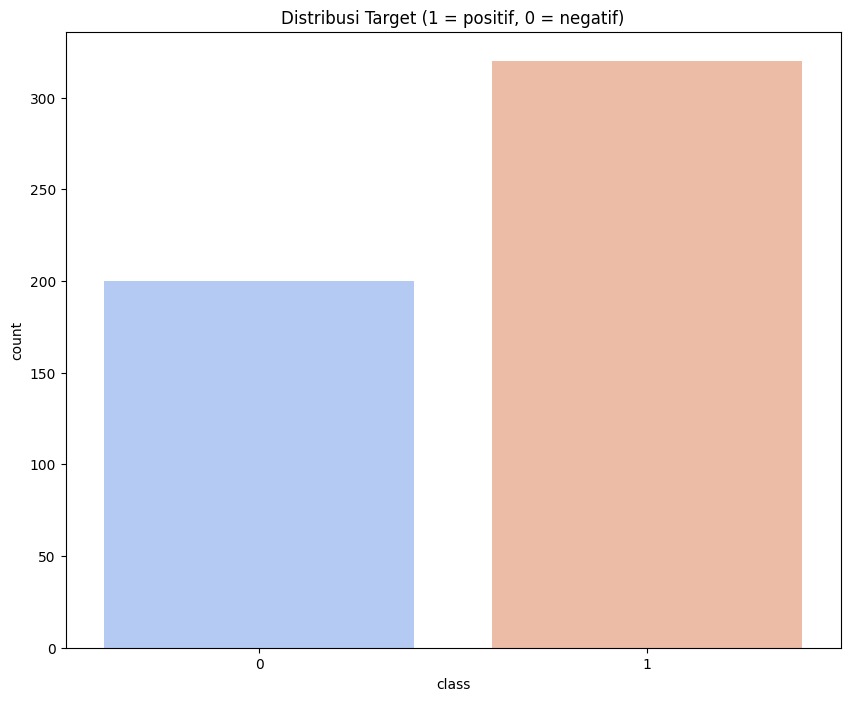

In [866]:
plt.figure(figsize=(10,8))
sns.countplot(x='class', data=dataset, palette="coolwarm")
plt.title("Distribusi Target (1 = positif, 0 = negatif)")
plt.show()

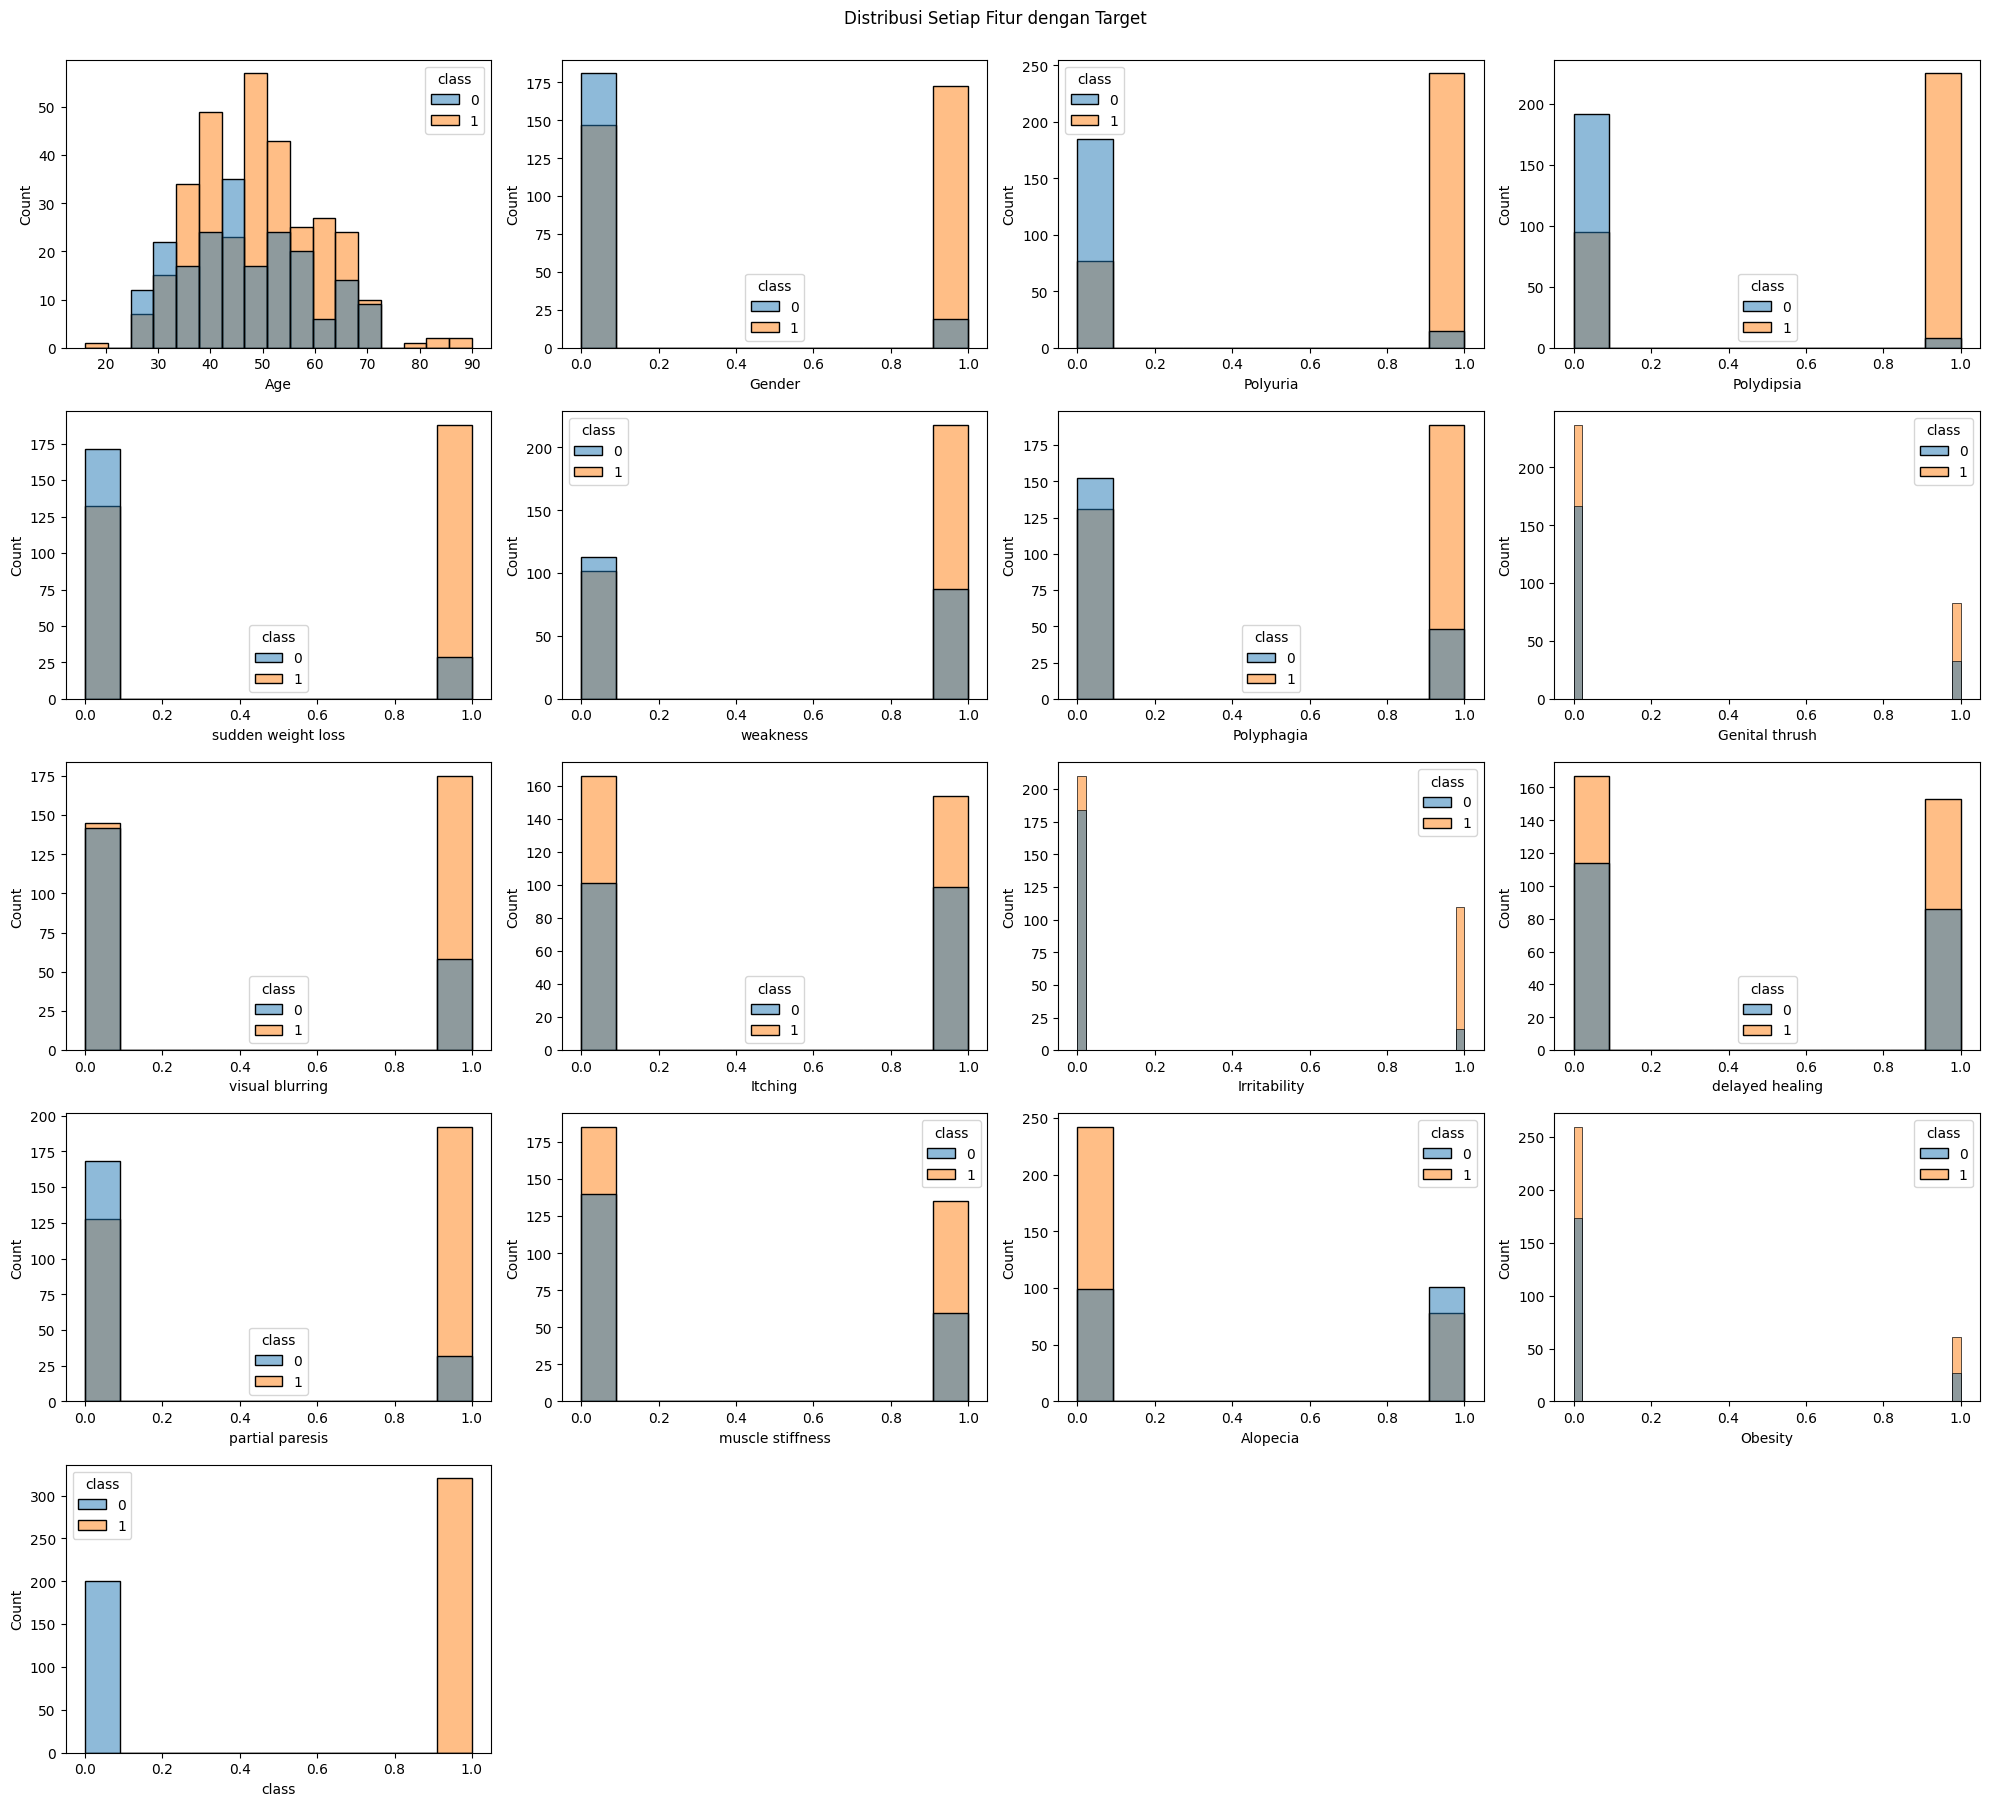

In [867]:
plt.figure(figsize=(20, 18))

for i, col in enumerate(dataset):
    plt.subplot(5, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset["class"])

plt.suptitle("Distribusi Setiap Fitur dengan Target", y=1.001)
plt.tight_layout()
plt.show()

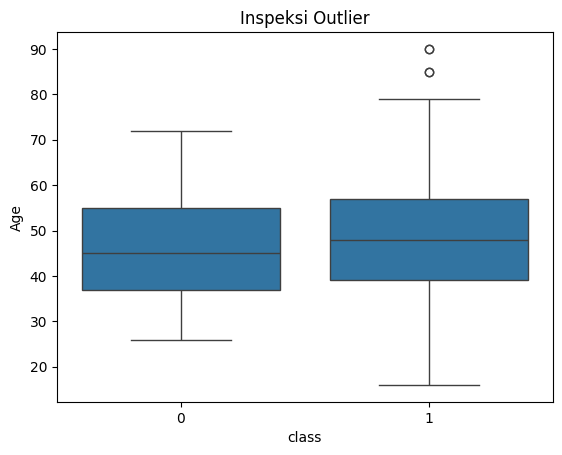

In [868]:
sns.boxplot(data=dataset, x="class", y="Age")
plt.title("Inspeksi Outlier")
plt.show()

Korelasi Matriks Kendall:
class                 1.000000
Polyuria              0.665922
Polydipsia            0.648734
Gender                0.449233
sudden weight loss    0.436568
partial paresis       0.432288
Polyphagia            0.342504
Irritability          0.299467
visual blurring       0.251300
weakness              0.243275
muscle stiffness      0.122474
Genital thrush        0.110288
Age                   0.091003
Obesity               0.072173
delayed healing       0.046980
Itching              -0.013384
Alopecia             -0.267512
Name: class, dtype: float64


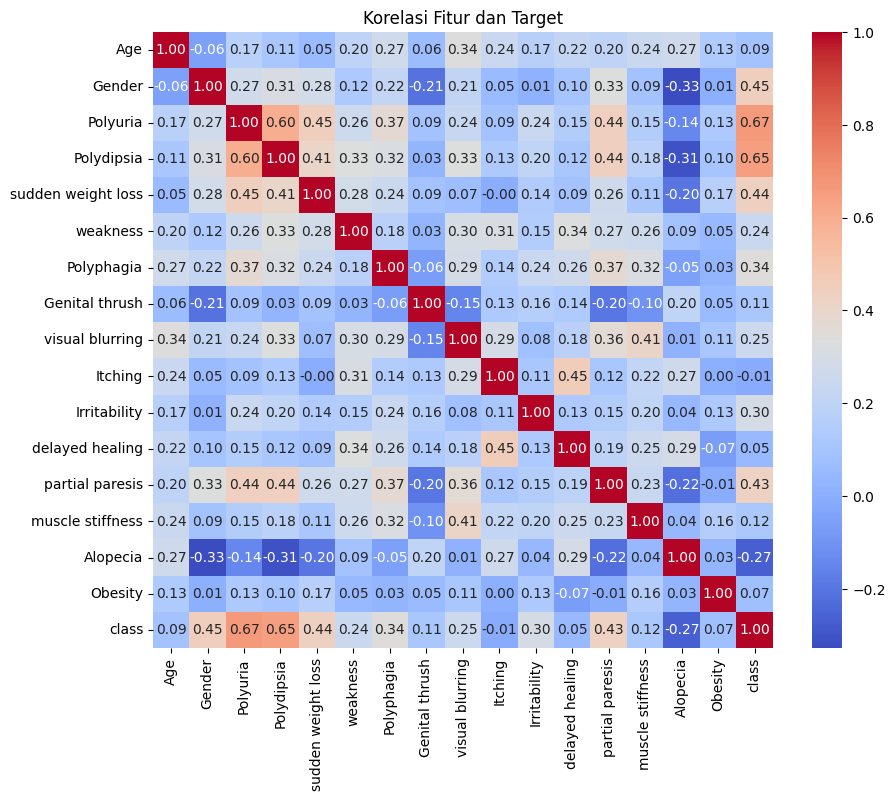

In [869]:
kendall_cor = dataset.corr(method='kendall')
print("Korelasi Matriks Kendall:")
print(kendall_cor['class'].sort_values(ascending=False))

plt.figure(figsize=(10,8))
sns.heatmap(kendall_cor, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Korelasi Fitur dan Target")
plt.show()

III. PREPROCESSING

In [ ]:
X = dataset.drop('class', axis=1).values
y = dataset['class'].values.reshape(-1,1)

1. Feature Scaling

In [871]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

print("\nFitur sebelum scaling:")
print(X[:5])

print("\nFitur setelah scaling:")
print(X_scaled[:5])


Fitur sebelum scaling:
[[40  0  0  1  0  1  0  0  0  1  0  1  0  1  1  1]
 [58  0  0  0  0  1  0  0  1  0  0  0  1  0  1  0]
 [41  0  1  0  0  1  1  0  0  1  0  1  0  1  1  0]
 [45  0  0  0  1  1  1  1  0  1  0  1  0  0  0  0]
 [60  0  1  1  1  1  1  0  1  1  1  1  1  1  1  1]]

Fitur setelah scaling:
[[-0.6613669  -0.76509206 -0.99233705  1.10984668 -0.84626923  0.83959397
  -0.91512613 -0.53584393 -0.90102535  1.02729546 -0.56550593  1.08431186
  -0.86991767  1.29099445  1.38022749  2.21564684]
 [ 0.82136224 -0.76509206 -0.99233705 -0.90102535 -0.84626923  0.83959397
  -0.91512613 -0.53584393  1.10984668 -0.97342978 -0.56550593 -0.9222439
   1.14953407 -0.77459667  1.38022749 -0.45133547]
 [-0.57899306 -0.76509206  1.00772212 -0.90102535 -0.84626923  0.83959397
   1.09274555 -0.53584393 -0.90102535  1.02729546 -0.56550593  1.08431186
  -0.86991767  1.29099445  1.38022749 -0.45133547]
 [-0.24949769 -0.76509206 -0.99233705 -0.90102535  1.18165704  0.83959397
   1.09274555  1.86621505 

2. Split Data

In [872]:
m = len(X_scaled)
split = int(0.8 * m)

indices = np.arange(m)
np.random.shuffle(indices)

train_idx = indices[:split]
test_idx = indices[split:]

# ambil data sesuai index
X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (416, 16)
X_test : (104, 16)


IV. Modeling

In [873]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

y_pred_prob = sigmoid(X_test @ w + b)

def train_logistic(X, y, lr=0.01, epochs=1000):
    m, n = X.shape
    w = np.zeros((n,1))
    b = 0
    losses = []

    for i in range(epochs):
        z = np.dot(X, w) + b
        y_pred = 1 / (1 + np.exp(-z))

        loss = -(1/m) * np.sum(y*np.log(y_pred+1e-8) + (1-y)*np.log(1-y_pred+1e-8))
        losses.append(loss)

        dw = (1/m) * np.dot(X.T, (y_pred -y))
        db = (1/m) * np.sum(y_pred - y)

        w-= lr * dw
        b -= lr * db

        if i % 100 == 0:
            print(f"Epoch {i}, Loss: {loss:.4f}")

    return w, b, losses

def predict(X, w, b):
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    return (y_pred >= 0.5).astype(int)

In [874]:
w, b, losses = train_logistic(X_train, y_train, lr=0.1, epochs=1000)
y_pred = predict(X_test, w, b)
accuracy = np.mean(y_pred == y_test) * 100
print(f"Akurasi test: {accuracy:.2f}%")

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.2615
Epoch 200, Loss: 0.2260
Epoch 300, Loss: 0.2106
Epoch 400, Loss: 0.2019
Epoch 500, Loss: 0.1964
Epoch 600, Loss: 0.1925
Epoch 700, Loss: 0.1896
Epoch 800, Loss: 0.1875
Epoch 900, Loss: 0.1858
Akurasi test: 95.19%


1. Loss vs Epoch

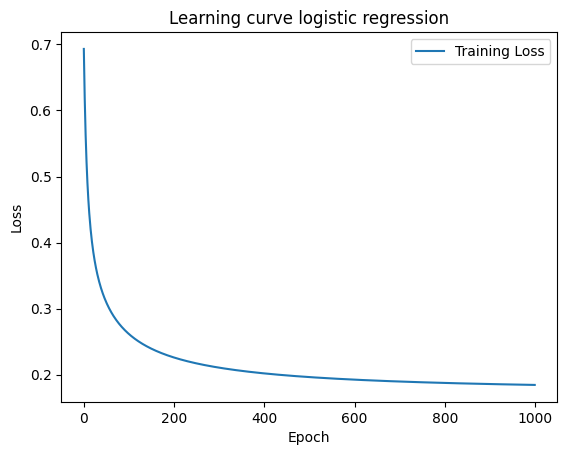

In [875]:
plt.plot(losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning curve logistic regression")
plt.legend()
plt.show()

cara baca grafik di atas :
- titik awal 0.69 itu setara 50:50 >> normal buat awal training
- turun tajam di 0-100 epoch : optimizer cepat mnemukan arah yg benar > lagi belajar
- ke 200-300 epoch : loss masih turun, tapi semakin pelan
- disekitar 0.18 di epoch 1000, artinya rata2 prediksi untuk kelas bener cukup yakin (kira2 epoch 0.8-0.85)
- loss yg terus menurun itu baik tp blm menjamin dia overfitting atau underfitting

V. EVALUASI

1. Confusion Matrix

In [876]:
def confusion_matrix(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    return np.array([[TN, FP],
                     [FN, TP]])

def plot_confusion_matrix(cm):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, cmap="Blues")

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)

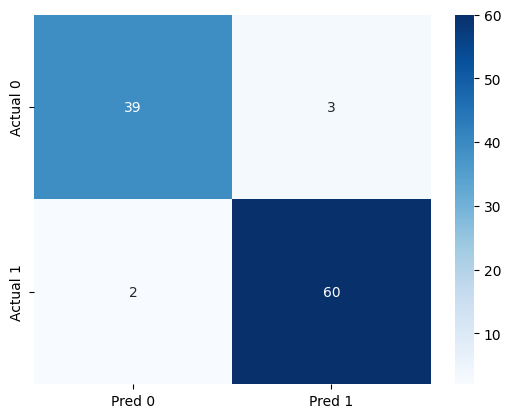

In [877]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0','Pred 1'], yticklabels=['Actual 0','Actual 1'])
plt.show()

In [878]:
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    cm = confusion_matrix(y_true, y_pred)
    total = np.sum(cm)

    accuracy  = (cm[0,0] + cm[1,1]) / total
    precision = cm[1,1] / (cm[0,1] + cm[1,1]) if (cm[0,1] + cm[1,1]) > 0 else 0
    recall    = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    f1_score  = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n=== Evaluasi {dataset_name} ===")
    print("Confusion Matrix:\n", cm)
    print(f"Akurasi  : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1_score:.4f}")

evaluate_model(y_test, y_pred, "Test Set")


=== Evaluasi Test Set ===
Confusion Matrix:
 [[39  3]
 [ 2 60]]
Akurasi  : 0.9519
Precision: 0.9524
Recall   : 0.9677
F1-Score : 0.9600


2. ROC Auc

In [879]:
def compute_roc_auc(y_true, y_scores):
    desc_score_indices = np.argsort(-y_scores)
    y_true = y_true[desc_score_indices]
    y_scores = y_scores[desc_score_indices]

    tpr = []
    fpr = []
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    TP = 0
    FP = 0

    for i in range(len(y_true)):
        if y_true[i] == 1:
            TP += 1
        else:
            FP += 1
        tpr.append(TP / P)
        fpr.append(FP / N)

        tpr = [0] + tpr + [1]
        fpr = [0] + fpr + [1]
        aus = np.trapz(tpr, fpr)

        return np.array(fpr), np.array(tpr), auc
    
def plot_auc_curve(y_true, y_scores):
    fpr, tpr, auc = compute_roc_auc(y_true, y_scores)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate (recall)")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

y_pred_prob = sigmoid(np.dot(X_test, w) + b)
fpr, tpr, auc = compute_roc_auc(y_test, y_pred_prob)
print("AUC:", auc)

AUC: 89.42307692307693


C:\Users\USER\AppData\Local\Temp\ipykernel_19832\1320755489.py:19: RuntimeWarning: invalid value encountered in scalar divide
  tpr.append(TP / P)
C:\Users\USER\AppData\Local\Temp\ipykernel_19832\1320755489.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aus = np.trapz(tpr, fpr)


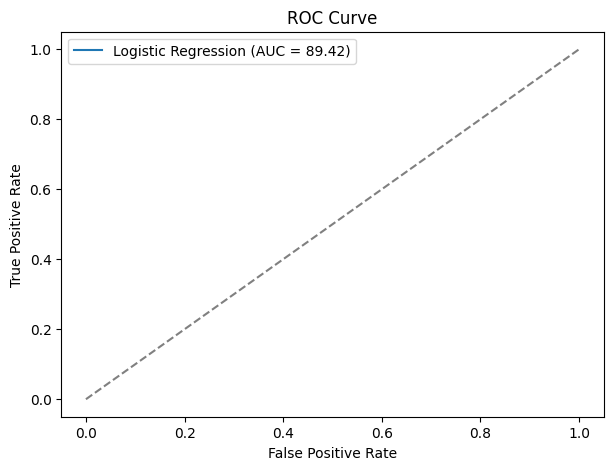

In [880]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

VI. FEATURE IMPORTANCE

               Feature  Coefficient  Odds_Ratio
3           Polydipsia     1.592859    4.917787
2             Polyuria     1.592157    4.914340
1               Gender     1.575359    4.832476
9              Itching    -0.910253    0.402422
10        Irritability     0.845709    2.329629
7       Genital thrush     0.655398    1.925908
12     partial paresis     0.416401    1.516494
6           Polyphagia     0.387392    1.473134
8      visual blurring     0.374385    1.454097
11     delayed healing    -0.346690    0.707024
0                  Age    -0.329593    0.719217
5             weakness     0.224582    1.251799
13    muscle stiffness    -0.213490    0.807760
4   sudden weight loss     0.198887    1.220044
14            Alopecia     0.033173    1.033729
15             Obesity     0.019519    1.019711


C:\Users\USER\AppData\Local\Temp\ipykernel_19832\16207490.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')


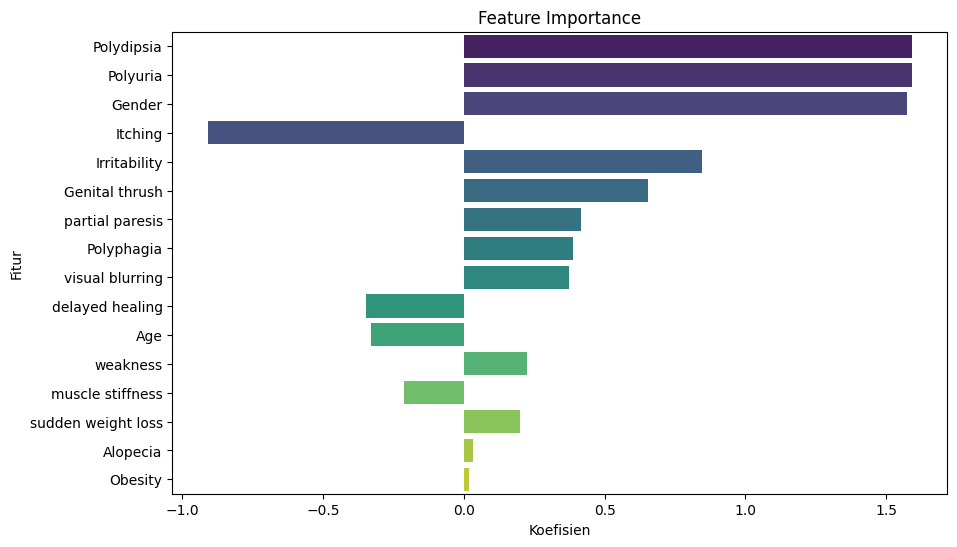

In [881]:
feature_names = dataset.columns.drop('class')
coef = w.flatten()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef,
    'Odds_Ratio': np.exp(coef)
})

feature_importance['abs_coef'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='abs_coef', ascending=False)

print(feature_importance[['Feature', 'Coefficient', 'Odds_Ratio']])

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')
plt.title("Feature Importance")
plt.xlabel("Koefisien")
plt.ylabel("Fitur")
plt.show()